In [215]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [231]:
# ------------------- Paths -------------------
RUN_DIR = Path("../runs")
TIMESERIES_DIR = Path("../data/time_series")
METRICS_DIR = Path("../ensemble_metrics")

In [246]:
# run_pattern = "total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed*"
# run_pattern = "chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed*"
# run_pattern = "chirps_v3_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed*"
run_pattern = "mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed*"

matched_paths = sorted(RUN_DIR.glob(f"{run_pattern}/validation/model_epoch030/validation_results.p"))
print(f"Found {len(matched_paths)} runs: {[p.parts[-4] for p in matched_paths]}")

Found 8 runs: ['mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed111_1304_215518', 'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed222_1304_231944', 'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed333_1404_060852', 'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed444_1404_073505', 'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed555_1404_090124', 'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed666_1404_102745', 'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed777_1404_115406', 'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed888_1404_132031']


In [247]:
# metrics_name = run_pattern.split("_seed")[0]
# metrics = pd.read_csv(METRICS_DIR / f"{metrics_name}.csv")
# metrics.head()

In [248]:
# df = metrics.copy().sort_values("NSE")

# smallest_id = df.iloc[0]["basin_id"]
# middle_id   = df.iloc[len(df)//2]["basin_id"]
# largest_id  = df.iloc[-1]["basin_id"]

# smallest_id, middle_id, largest_id

In [249]:
# Load all runs
all_runs_data = []
for file_path in matched_paths:
    with open(file_path, "rb") as f:
        all_runs_data.append(pickle.load(f))

# Average the simulated flows across seeds, per basin
ensemble_data = {}

for basin_id in all_runs_data[0].keys():
    # Stack simulated flows from all seeds: shape (n_seeds, n_timesteps, time_step)
    sims = np.stack([
        run[basin_id]['1D']['xr']['streamflow_sim'].values #['QObs(mm/d)_sim'].values 
        for run in all_runs_data
    ], axis=0)
    
    mean_sim = np.mean(sims, axis=0)  # Average across seeds
    
    # Copy structure from first run, replace sim with ensemble mean
    xr_ensemble = all_runs_data[0][basin_id]['1D']['xr'].copy()
    xr_ensemble['streamflow_sim'].values[:] = mean_sim #['QObs(mm/d)_sim'].values[:] = mean_sim #
    
    ensemble_data[basin_id] = {'1D': {'xr': xr_ensemble}}

ensemble_data

{'camels_01411300': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:         (date: 3652, time_step: 1)
   Coordinates:
     * date            (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
     * time_step       (time_step) int64 8B 0
   Data variables:
       streamflow_obs  (date, time_step) float32 15kB 1.75 1.99 2.85 ... 0.46 0.55
       streamflow_sim  (date, time_step) float32 15kB 1.372 1.695 ... 0.5679 0.6391}},
 'camels_01487000': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:         (date: 3652, time_step: 1)
   Coordinates:
     * date            (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
     * time_step       (time_step) int64 8B 0
   Data variables:
       streamflow_obs  (date, time_step) float32 15kB 1.43 1.88 2.14 ... 1.47 1.58
       streamflow_sim  (date, time_step) float32 15kB 1.661 2.205 ... 1.3 1.518}},
 'camels_01491000': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:         (date: 3652, time_step: 1)
   Coordinates

In [250]:
# gauge_id = 'camels_01411300'
# gauge_id = 'camels_07263295'
gauge_id = 'camels_02464000'
ds = ensemble_data[gauge_id]['1D']['xr']
ds


<xarray.Dataset> Size: 58kB
Dimensions:         (date: 3652, time_step: 1)
Coordinates:
  * date            (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
  * time_step       (time_step) int64 8B 0
Data variables:
    streamflow_obs  (date, time_step) float32 15kB 7.29 3.09 1.48 ... 0.02 0.02
    streamflow_sim  (date, time_step) float32 15kB 7.815 4.367 ... 0.1075 0.1268

In [251]:
time = ds['date'].values
time

array(['1989-10-01T00:00:00.000000000', '1989-10-02T00:00:00.000000000',
       '1989-10-03T00:00:00.000000000', ...,
       '1999-09-28T00:00:00.000000000', '1999-09-29T00:00:00.000000000',
       '1999-09-30T00:00:00.000000000'], dtype='datetime64[ns]')

In [252]:
ds_forcings = xr.open_dataset(TIMESERIES_DIR / f"{gauge_id}.nc")
ds_forcings

<xarray.Dataset> Size: 438kB
Dimensions:                           (date: 7305)
Coordinates:
    basin                             <U15 60B ...
  * date                              (date) datetime64[ns] 58kB 1989-01-01 ....
Data variables:
    chirps_precipitation              (date) float32 29kB ...
    era5land_total_precipitation      (date) float32 29kB ...
    total_precipitation_sum           (date) float32 29kB ...
    temperature_2m_max                (date) float32 29kB ...
    temperature_2m_min                (date) float32 29kB ...
    surface_net_solar_radiation_mean  (date) float32 29kB ...
    streamflow                        (date) float32 29kB ...
    mswep_precipitation               (date) float64 58kB ...
    camels_precipitation              (date) float64 58kB ...
    chirps_v3_precipitation           (date) float64 58kB ...
Attributes:
    Citation:  Funk, Chris, Pete Peterson, Martin Landsfeld, Diego Pedreros, ...
    License:   To the extent possible under the law, Pete Peterson has waived...
    Product:   CHIRPS
    Released:  2024-11-18
    Sources:   CHIRPS: Rainfall Estimates from Rain Gauge and Satellite Obser...
    Units:     precipitation [mm]
    Version:   1.1

In [253]:
precip_name = run_pattern.split("_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5")[0]
precip_name

'mswep_precipitation'

In [254]:
if precip_name == "total_precipitation_sum":
    title_precip_name = "caravan_precipitation"
else:
    title_precip_name = precip_name

In [255]:
pr_ds = ds_forcings[f"{precip_name}"].sel(date=time)
pr_ds

<xarray.DataArray 'mswep_precipitation' (date: 3652)> Size: 29kB
[3652 values with dtype=float64]
Coordinates:
    basin    <U15 60B ...
  * date     (date) datetime64[ns] 29kB 1989-10-01 1989-10-02 ... 1999-09-30

In [256]:
metrics_name = run_pattern.split("_seed")[0]
metrics_name

'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5'

In [257]:
metrics = pd.read_csv(METRICS_DIR / f"{metrics_name}.csv")
metrics= metrics[metrics['basin_id'] == gauge_id]
metrics

,basin_id,NSE,MSE,RMSE,KGE,Alpha-NSE,Pearson-r,Beta-KGE,Beta-NSE,FHV,FMS,FLV,Peak-Timing,Missed-Peaks,Peak-MAPE
66,camels_02464000,0.883197,1.328116,1.152439,0.936462,0.986315,0.940927,1.018979,0.009309,2.284662,-27.090967,48.466694,0.15,0.263158,22.109287


In [258]:
NSE = metrics['NSE'].values[0]

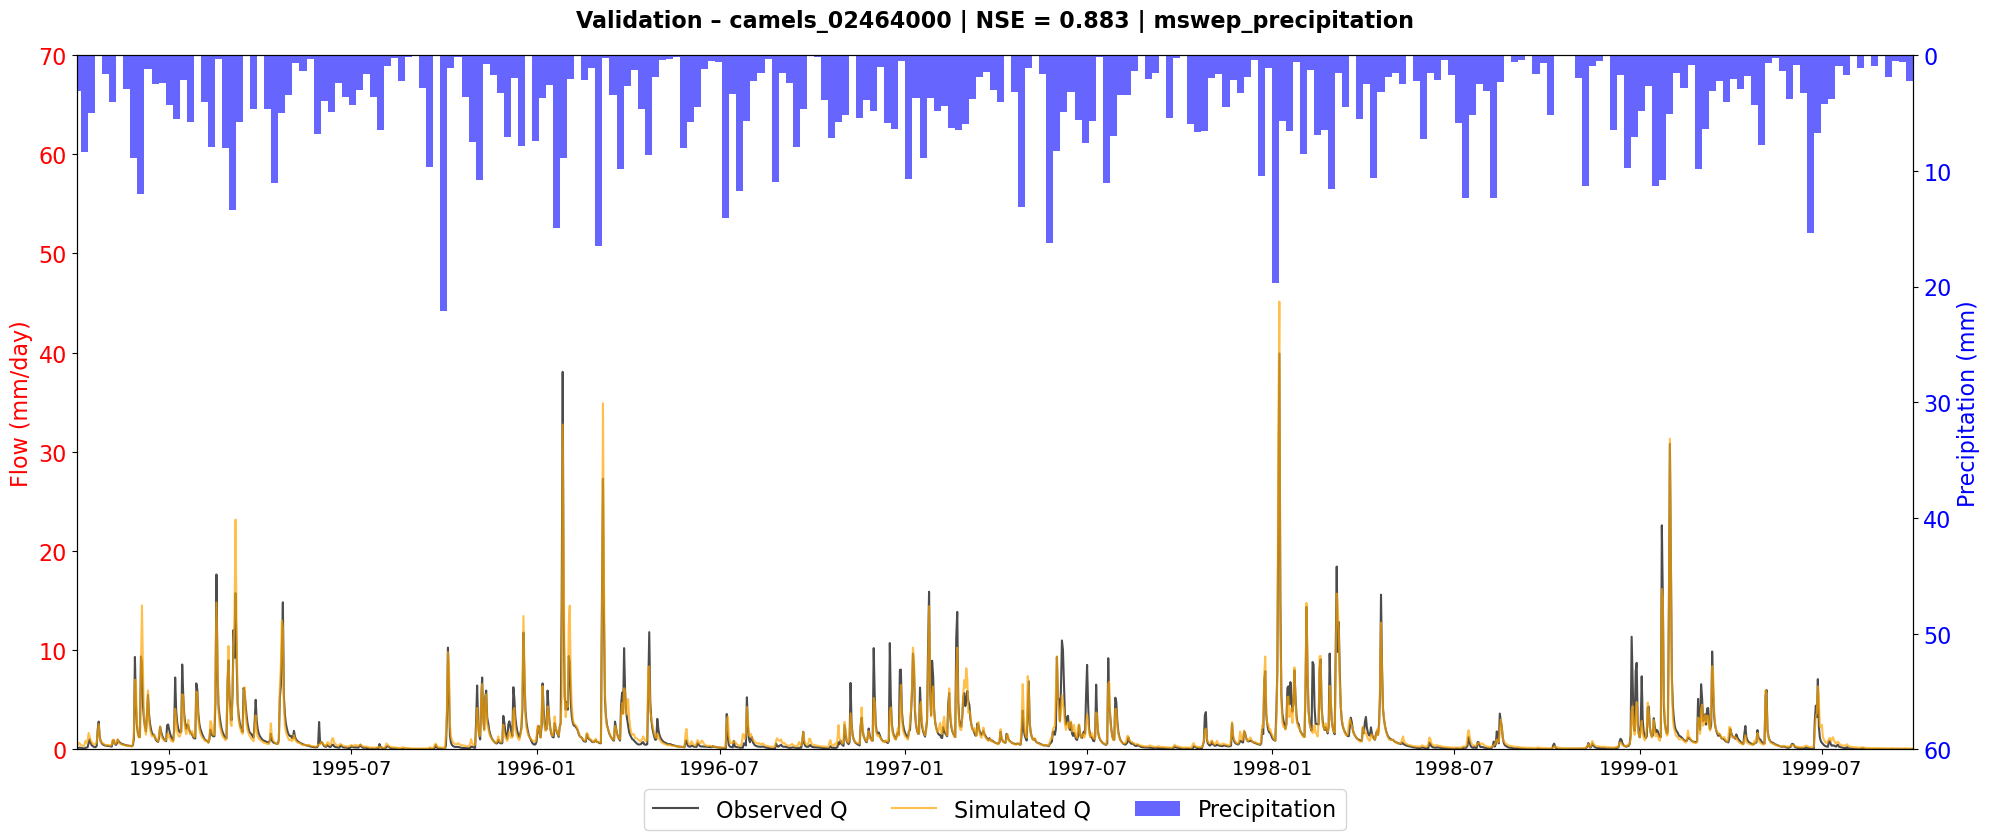

In [259]:
# --------------------------------------------------
# Extract streamflow as pandas
# --------------------------------------------------
time = ds['date'].values
obs = ds['streamflow_obs'].values.squeeze()
sim = ds['streamflow_sim'].values.squeeze()

flow_df = pd.DataFrame({
    "obs": obs,
    "sim": sim
}, index=pd.to_datetime(time))

# --------------------------------------------------
# Precipitation: convert to pandas and aggregate
# --------------------------------------------------
precip = pr_ds.to_pandas()  # pr_ds already aligned to validation period
window = "7D"  # e.g., 7-day mean for visualization
precip_agg = precip.resample(window).mean()  # or .sum() if you prefer totals

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax_flow = plt.subplots(figsize=(20, 8))

# Streamflow (line)
ax_flow.plot(flow_df.index, flow_df['obs'], color="black", label="Observed Q", alpha=0.7)
ax_flow.plot(flow_df.index, flow_df['sim'], color="orange", label="Simulated Q", alpha=0.7)
ax_flow.set_ylabel("Flow (mm/day)",fontsize=16, color="red")
ax_flow.set_ylim(0,70)
ax_flow.tick_params(axis="y", labelcolor="red",labelsize=16)

# Precipitation (bar, aggregated)
ax_precip = ax_flow.twinx()
ax_precip.bar(
    precip_agg.index,
    precip_agg.values,
    width=pd.Timedelta(window).days,
    color="blue",
    alpha=0.6,
    label="Precipitation"
)
ax_precip.set_ylabel("Precipitation (mm)",fontsize=16, color="blue")
# ax_precip.invert_yaxis()  # downward bars
ax_precip.tick_params(axis="y", labelcolor="blue",labelsize=16)
ax_precip.set_ylim(60,0)

# Optional: set x-axis limits (e.g., zoom to a period)
# test_start_date= "01/10/1989"
# test_end_date = "30/09/1994"

test_start_date= "01/10/1994"
test_end_date = "30/09/1999"

ax_flow.set_xlim(pd.to_datetime(test_start_date, dayfirst=True), 
                 pd.to_datetime(test_end_date, dayfirst=True))
ax_precip.set_xlim(ax_flow.get_xlim())
ax_flow.tick_params(axis="x", labelsize=14)


# Title
fig.suptitle(f"Validation – {gauge_id} | NSE = {NSE:.3f} | {title_precip_name}", fontsize=16, fontweight="bold")
# fig.suptitle(f"Validation – {gauge_id} | {precip_name}", fontsize=16, fontweight="bold")

# Legend
lines1, labels1 = ax_flow.get_legend_handles_labels()
lines2, labels2 = ax_precip.get_legend_handles_labels()

fig.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.06),
    fontsize=16
)

plt.tight_layout()
plt.show()
